# Tensorflow Basics

In [1]:
from sklearn import datasets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

In [2]:
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Softmax, Flatten, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

## Utils

In [42]:
def plot_history(history):
    # Extract metrics from the training history
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    epochs = range(1, len(loss) + 1)

    # Create side-by-side plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss plot
    ax1.plot(epochs, loss, label='Train Loss')
    ax1.plot(epochs, val_loss, '--', label='Validation Loss')

    ax1.set_title('Loss over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')

    ax1.grid(True)
    ax1.legend()

    # Accuracy plot
    ax2.plot(epochs, acc, label='Train Accuracy')
    ax2.plot(epochs, val_acc, '--', label='Validation Accuracy')

    ax2.set_title('Accuracy over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')

    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [3]:
class DecisionBoundaryCallback(tf.keras.callbacks.Callback):
    def __init__(self, X, y, interval=30, h=0.03):
        """
        Initializes the callback with training data and meshgrid setup.

        Args:
            X (ndarray): Training features (2D input).
            y (ndarray): Training labels.
            interval (int): Plotting interval in epochs.
            h (float): Step size for meshgrid resolution.
        """
        self.X = X
        self.y = y
        self.interval = interval

        # Automatically generate meshgrid and grid
        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
        self.xx, self.yy = np.meshgrid(
            np.arange(x_min, x_max, h),
            np.arange(y_min, y_max, h)
        )
        self.grid = np.c_[self.xx.ravel(), self.yy.ravel()]

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.interval == 0:
            clear_output(wait=True)

            Z = self.model.predict(self.grid, verbose=0)
            Z = np.argmax(Z, axis=1).reshape(self.xx.shape)

            plt.figure(figsize=(8, 6))
            plt.pcolormesh(self.xx, self.yy, Z, cmap='coolwarm', shading='auto', alpha=0.3)
            plt.scatter(self.X[:, 0], self.X[:, 1], c=self.y, cmap='coolwarm', s=20, edgecolors='k')
            plt.title(f"Decision Boundary at Epoch {epoch + 1}")
            plt.xlabel("X1")
            plt.ylabel("X2")
            plt.axis("equal")
            plt.grid(True)
            plt.show()

In [4]:
class DecisionBoundaryPlotter:
    def __init__(self, X, y, h=0.03):
        """
        Initialize with training data and prepare meshgrid.
        """
        self.X = X
        self.y = y
        self.h = h

        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
        self.xx, self.yy = np.meshgrid(
            np.arange(x_min, x_max, h),
            np.arange(y_min, y_max, h)
        )
        self.grid = np.c_[self.xx.ravel(), self.yy.ravel()]

    def plot(self, Z_pred, title="Decision Boundary"):
        """
        Plot decision boundary given predictions on the meshgrid.

        Z_pred should be the model's raw predictions on self.grid
        """
        Z = np.argmax(Z_pred, axis=1).reshape(self.xx.shape)

        plt.figure(figsize=(8, 6))
        plt.pcolormesh(self.xx, self.yy, Z, cmap='coolwarm', shading='auto', alpha=0.4)
        plt.scatter(self.X[:, 0], self.X[:, 1], c=self.y, cmap='coolwarm', s=20, edgecolors='k')
        plt.title(title)
        plt.xlabel("X1")
        plt.ylabel("X2")
        plt.axis("equal")
        plt.grid(True)
        plt.show()


## Binary Classification with Synthetic Moons Dataset

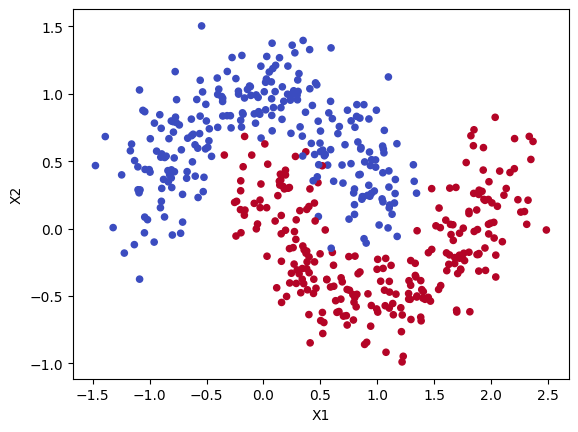

In [41]:
# Generate the data
X, y = datasets.make_moons(n_samples=500, noise=0.2, random_state=42)

plotter = DecisionBoundaryPlotter(X, y)
callback = DecisionBoundaryCallback(X, y, interval=3)

plt.scatter(X[:,0], X[:,1], cmap='coolwarm', c=y, s=20)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [23]:
# Build the neural network:
# - Input layer receives the 2 input features (x1 and x2)
# - Hidden Dense layer with 12 neurons and ReLU activation learns nonlinear patterns
# - Output layer with 2 neurons produces one raw score (logit) for each class
# - Model connects the inputs to the outputs into a complete computation graph

# Run the model on X to produce raw output scores (logits).

# Apply softmax to convert logits into probabilities.
# The probabilities for all classes sum to 1.

# Plot predictions over a 2D grid.
# This visualizes the learned decision boundary.

# Define the loss function.
# SparseCategoricalCrossentropy measures how different
# the predicted class probabilities are from the true labels.

# Use from_logits=True when the model outputs raw logits.
# Use from_logits=False when the model already outputs probabilities.

# Compile the model:
# - optimizer controls how weights are updated
# - loss defines the training objective
# - metrics track model performance during training

# During training:
# - the model makes predictions
# - the loss is computed
# - gradients are calculated with backpropagation
# - weights are updated to reduce the loss

# Accuracy measures the fraction of correctly classified samples.

## Multi-Class Classification on MNIST Digits

In [26]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


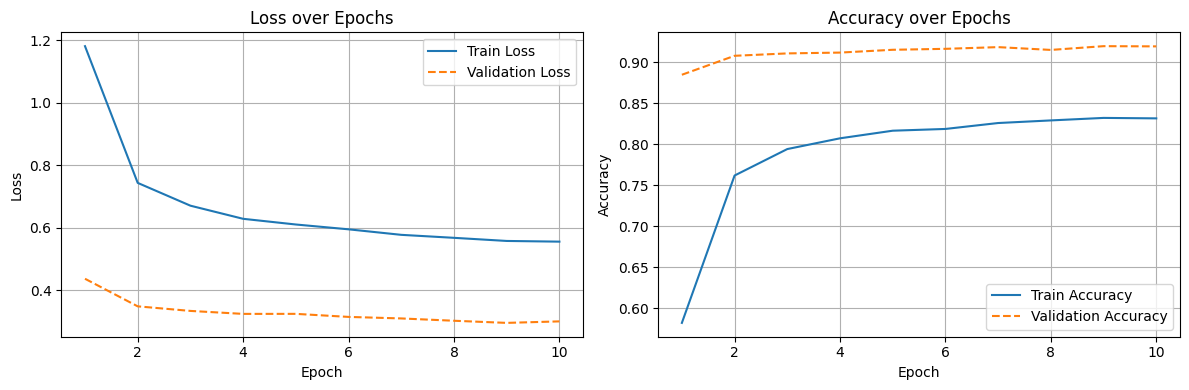

In [43]:
# plot_history(history)

In [ ]:
# Select a random test example


# Add a batch dimension so the sample has shape (1, height, width)


# Run the model to get raw output scores (logits)


# Convert logits into probabilities using softmax


# Select the class with the highest probability


# Get the confidence of the predicted class


# Get the true label for comparison


# Display prediction result and image

In [ ]:
# Generate a random sample with shape (1, 28, 28) — like a fake MNIST image

# Predict the class probabilities using the trained model

# Get the predicted class (index of the highest probability)

# Get the confidence (the actual highest probability)
